Dataset shape: (85, 2)
Least-squares weights for log(count) = w0 + w1 * year: [-6.93553490e+02  3.55358877e-01]
Approximate doubling time implied by the fit: 1.95 years
Original-space RMSE: 669,327,200 transistors
Original-space MAE: 326,742,663 transistors


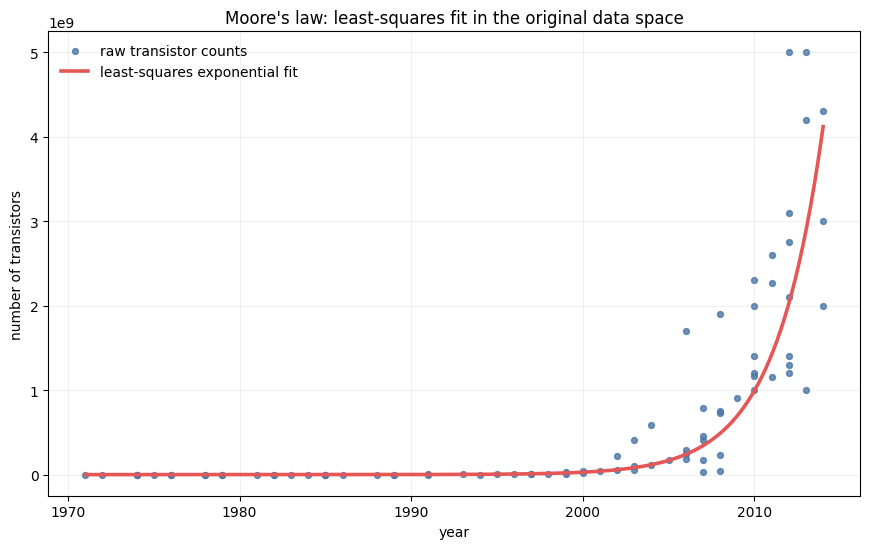

In [1]:
# QUESTION HANDLED: Exercise 10.4(b) - Moore's law.
# ---------------------------------------------------------------------
# Part (a) suggests the correct nonlinear transformation: keep the input as the
# release year x, but transform the output transistor count y with a logarithm.
# If transistor counts grow approximately exponentially over time, then log(y)
# should be approximately linear in x.
#
# We therefore fit the transformed model
#
#     log(y) ~ w0 + w1 * x
#
# by minimizing a Least Squares cost over the transformed outputs.  After solving
# for w0 and w1, we map the fitted line back to the original data space using
#
#     y_hat = exp(w0 + w1 * x)
#
# so the final curve can be plotted directly against the original transistor-count
# data as requested in Figure 10.18.
# ---------------------------------------------------------------------
# Textbook equations used here: after the log transform we fit the affine model
# written with appended inputs in Equation (10.3), then map predictions back to
# the original transistor-count space.

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Use a light plotting style explicitly so the figure remains readable regardless
# of the notebook theme used by the current Jupyter session.
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

# ---------------------------------------------------------------------
# Load the official Chapter 10 Moore's law dataset.  Each row contains one chip:
# column 0 is the release year and column 1 is the number of transistors.
# ---------------------------------------------------------------------
moore_path = Path("chapter_10_datasets") / "transistor_counts.csv"
moore_data = np.loadtxt(moore_path, delimiter=",")
years = moore_data[:, 0:1]
transistor_counts = moore_data[:, 1:2]

# Transform the output so exponential growth becomes linear.
log_counts = np.log(transistor_counts)

# ---------------------------------------------------------------------
# Formulate the Least Squares problem in the transformed space.
# The linear model is z_hat = w0 + w1 * x where z = log(y), so the design matrix
# contains a bias column of ones and the raw year values.
# ---------------------------------------------------------------------
X_design = np.hstack([np.ones_like(years), years])
weights = np.linalg.lstsq(X_design, log_counts, rcond=None)[0]

# Evaluate the fitted model on a dense grid of years so the recovered curve is
# smooth when plotted back in the original transistor-count space.
year_grid = np.linspace(years.min(), years.max(), 400).reshape(-1, 1)
X_grid = np.hstack([np.ones_like(year_grid), year_grid])
log_count_fit = X_grid @ weights
transistor_count_fit = np.exp(log_count_fit)

# Basic summary statistics help interpret the fitted exponential trend.
transistor_count_pred = np.exp(X_design @ weights)
rmse = np.sqrt(np.mean((transistor_count_pred - transistor_counts) ** 2))
mae = np.mean(np.abs(transistor_count_pred - transistor_counts))
doubling_time_years = np.log(2.0) / weights[1, 0]

print(f"Dataset shape: {moore_data.shape}")
print(f"Least-squares weights for log(count) = w0 + w1 * year: {weights.ravel()}")
print(f"Approximate doubling time implied by the fit: {doubling_time_years:.2f} years")
print(f"Original-space RMSE: {rmse:,.0f} transistors")
print(f"Original-space MAE: {mae:,.0f} transistors")

# ---------------------------------------------------------------------
# Plot the raw data and the fitted exponential curve in the original data space,
# matching the spirit of Figure 10.18.
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.8, 5.6))
ax.scatter(
    years,
    transistor_counts,
    s=18,
    color="#4C78A8",
    alpha=0.82,
    label="raw transistor counts",
)
ax.plot(
    year_grid,
    transistor_count_fit,
    color="#E45756",
    linewidth=2.6,
    label="least-squares exponential fit",
)
ax.set_title("Moore's law: least-squares fit in the original data space")
ax.set_xlabel("year")
ax.set_ylabel("number of transistors")
ax.grid(alpha=0.18)
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


Dataset shape: (5, 2)
Least-squares weights for 1 / I = w0 + w1 * x: [0.20101737 0.00692297]
Transformed-space RMSE: 0.0221
Original-space RMSE: 0.1663
Original-space MAE: 0.1300


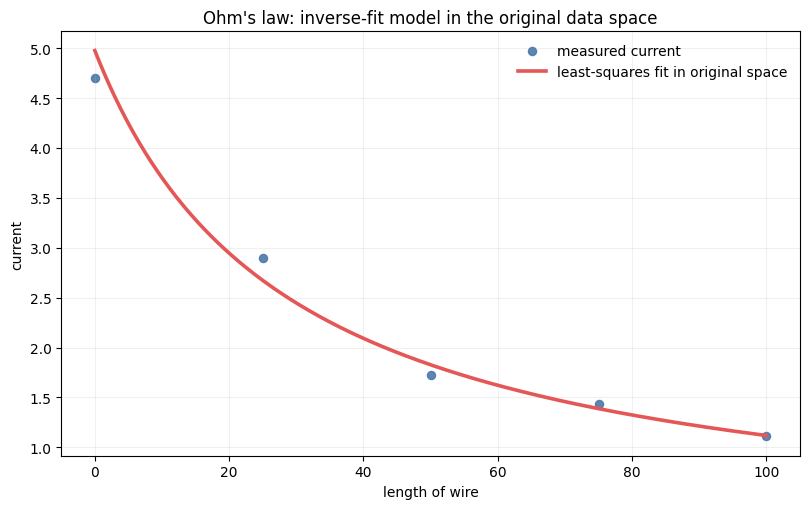

In [2]:
# QUESTION HANDLED: Exercise 10.5 - Ohm's law.
# ---------------------------------------------------------------------
# To make the current-versus-wire-length data linear, transform the output using
# a reciprocal.  If current follows a relation of the form
#
#     I(x) = 1 / (w0 + w1 * x),
#
# then the transformed output z = 1 / I satisfies the linear model
#
#     z ~ w0 + w1 * x.
#
# We therefore fit w0 and w1 by minimizing a Least Squares cost in the transformed
# space, then map the fitted line back to the original current scale with
#
#     I_hat(x) = 1 / (w0 + w1 * x).
# ---------------------------------------------------------------------
# Textbook equations used here: after the reciprocal transform we again fit the
# affine appended-input model in Equation (10.3), then invert the transform to
# plot the fitted curve in the original current scale.

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Keep the figure readable regardless of notebook theme.
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

# ---------------------------------------------------------------------
# Load the official Chapter 10 Ohm's law dataset.  Column 0 is wire length x in
# centimeters and column 1 is the measured current I.
# ---------------------------------------------------------------------
ohms_path = Path("chapter_10_datasets") / "ohms_data.csv"
ohms_data = np.loadtxt(ohms_path, delimiter=",")
wire_length = ohms_data[:, 0:1]
current = ohms_data[:, 1:2]

# Transform the output so the nonlinear inverse relationship becomes linear.
reciprocal_current = 1.0 / current

# ---------------------------------------------------------------------
# Form the Least Squares problem in transformed space.
# The model is z_hat = w0 + w1 * x where z = 1 / I.
# ---------------------------------------------------------------------
X_design = np.hstack([np.ones_like(wire_length), wire_length])
weights = np.linalg.lstsq(X_design, reciprocal_current, rcond=None)[0]

# Evaluate the fitted model on a dense grid so the recovered curve is smooth in
# the original current space.
wire_grid = np.linspace(wire_length.min(), wire_length.max(), 400).reshape(-1, 1)
X_grid = np.hstack([np.ones_like(wire_grid), wire_grid])
reciprocal_fit = X_grid @ weights
current_fit = 1.0 / reciprocal_fit

# Summaries in both transformed and original space clarify how the fit behaves.
current_pred = 1.0 / (X_design @ weights)
transformed_rmse = np.sqrt(np.mean((X_design @ weights - reciprocal_current) ** 2))
original_rmse = np.sqrt(np.mean((current_pred - current) ** 2))
original_mae = np.mean(np.abs(current_pred - current))

print(f"Dataset shape: {ohms_data.shape}")
print(f"Least-squares weights for 1 / I = w0 + w1 * x: {weights.ravel()}")
print(f"Transformed-space RMSE: {transformed_rmse:.4f}")
print(f"Original-space RMSE: {original_rmse:.4f}")
print(f"Original-space MAE: {original_mae:.4f}")

# ---------------------------------------------------------------------
# Plot the raw data with the fitted inverse curve in the original data space.
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.scatter(
    wire_length,
    current,
    s=34,
    color="#4C78A8",
    alpha=0.9,
    label="measured current",
)
ax.plot(
    wire_grid,
    current_fit,
    color="#E45756",
    linewidth=2.6,
    label="least-squares fit in original space",
)
ax.set_title("Ohm's law: inverse-fit model in the original data space")
ax.set_xlabel("length of wire")
ax.set_ylabel("current")
ax.grid(alpha=0.18)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


Dataset shape: (3, 150)
Final weights: [  5.02544764  -7.57459701 -13.93917038]
Best cost: 0.129769 at step 2000
Best misclassifications: 3
Final misclassifications: 3


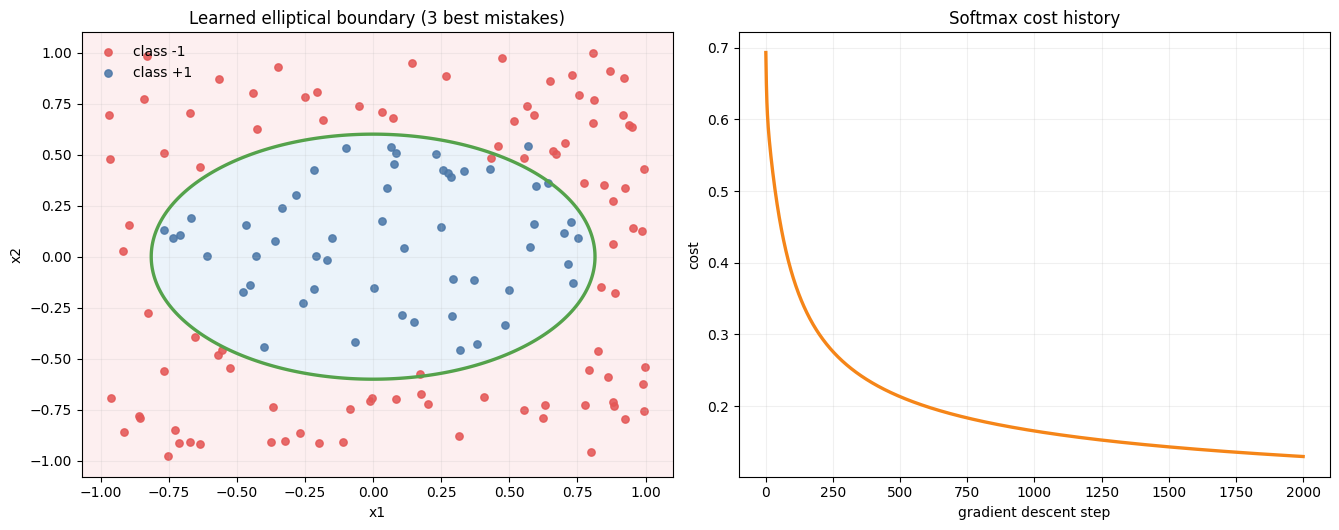

In [3]:
# QUESTION HANDLED: Exercise 10.7 - An elliptical decision boundary.
# ---------------------------------------------------------------------
# Repeat Example 10.5 using the feature map suggested in the chapter:
#
#     f1(x) = x1^2,   f2(x) = x2^2
#
# so the nonlinear classifier in the original input space takes the form
#
#     model(x) = w0 + w1 * x1^2 + w2 * x2^2.
#
# This corresponds to an ellipse-like decision boundary in the original plane.
# We minimize the two-class Softmax cost with gradient descent and use a cost-
# history plot to verify that optimization is learning a good fit, as requested.
# ---------------------------------------------------------------------
# Textbook equations used here: the two-class Softmax cost in Equation (10.31)
# and the elliptical nonlinear model in Equation (10.33).

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Keep the figure readable regardless of notebook theme.
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

# ---------------------------------------------------------------------
# Load the official ellipse dataset.  The first two rows are the coordinates and
# the third row contains labels in {-1, +1}.
# ---------------------------------------------------------------------
ellipse_path = Path("chapter_10_datasets") / "ellipse_2class_data.csv"
ellipse_data = np.loadtxt(ellipse_path, delimiter=",")
X_ellipse = ellipse_data[:2, :]
y_ellipse = ellipse_data[2, :]

# Nonlinear feature map from Example 10.5.
def ellipse_features(X):
    return np.vstack([np.ones((1, X.shape[1])), X[0:1, :] ** 2, X[1:2, :] ** 2])


def ellipse_model(weights, X):
    return weights @ ellipse_features(X)


def two_class_softmax_cost(weights, X, y):
    scores = ellipse_model(weights, X)
    return np.mean(np.logaddexp(0.0, -y * scores))


def two_class_softmax_gradient(weights, X, y):
    Phi = ellipse_features(X)
    scores = weights @ Phi
    margins = y * scores
    probs = 1.0 / (1.0 + np.exp(np.clip(margins, -60.0, 60.0)))
    return -(Phi @ (y * probs).T) / Phi.shape[1]


def misclassifications(weights, X, y):
    scores = ellipse_model(weights, X)
    predictions = np.sign(scores)
    predictions[predictions == 0] = 1
    return int(np.sum(predictions != y))


# ---------------------------------------------------------------------
# Run fixed-step gradient descent on the Softmax cost.  The cost history is the
# main diagnostic requested by the exercise, while the final misclassification
# count gives a direct sense of classification quality.
# ---------------------------------------------------------------------
alpha = 0.5
num_steps = 2000
weights = np.zeros(3)
weight_history = [weights.copy()]
cost_history = [two_class_softmax_cost(weights, X_ellipse, y_ellipse)]
mis_history = [misclassifications(weights, X_ellipse, y_ellipse)]

for _ in range(num_steps):
    gradient = two_class_softmax_gradient(weights, X_ellipse, y_ellipse)
    weights = weights - alpha * gradient
    weight_history.append(weights.copy())
    cost_history.append(two_class_softmax_cost(weights, X_ellipse, y_ellipse))
    mis_history.append(misclassifications(weights, X_ellipse, y_ellipse))

best_step = int(np.argmin(cost_history))
best_weights = weight_history[best_step]
best_cost = cost_history[best_step]
best_mis = mis_history[best_step]

print(f"Dataset shape: {ellipse_data.shape}")
print(f"Final weights: {weights}")
print(f"Best cost: {best_cost:.6f} at step {best_step}")
print(f"Best misclassifications: {best_mis}")
print(f"Final misclassifications: {mis_history[-1]}")

# ---------------------------------------------------------------------
# Visualize the learned boundary and the cost history.  The decision boundary is
# the zero contour of w0 + w1*x1^2 + w2*x2^2 in the original input space.
# ---------------------------------------------------------------------
xx1 = np.linspace(X_ellipse[0, :].min() - 0.1, X_ellipse[0, :].max() + 0.1, 300)
xx2 = np.linspace(X_ellipse[1, :].min() - 0.1, X_ellipse[1, :].max() + 0.1, 300)
XX1, XX2 = np.meshgrid(xx1, xx2)
X_grid = np.vstack([XX1.ravel(), XX2.ravel()])
score_grid = ellipse_model(best_weights, X_grid).reshape(XX1.shape)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))

# Left: data with the learned nonlinear boundary.
axes[0].contourf(
    XX1,
    XX2,
    score_grid,
    levels=[-1e9, 0.0, 1e9],
    colors=["#FDE2E4", "#DCEAF7"],
    alpha=0.55,
)
axes[0].contour(
    XX1,
    XX2,
    score_grid,
    levels=[0.0],
    colors=["#54A24B"],
    linewidths=2.4,
)
axes[0].scatter(
    X_ellipse[0, y_ellipse == -1],
    X_ellipse[1, y_ellipse == -1],
    s=28,
    color="#E45756",
    alpha=0.88,
    label="class -1",
)
axes[0].scatter(
    X_ellipse[0, y_ellipse == 1],
    X_ellipse[1, y_ellipse == 1],
    s=28,
    color="#4C78A8",
    alpha=0.88,
    label="class +1",
)
axes[0].set_title(f"Learned elliptical boundary ({best_mis} best mistakes)")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].grid(alpha=0.16)
axes[0].legend(frameon=False)

# Right: cost history, which should steadily decrease if optimization is working.
axes[1].plot(cost_history, color="#F58518", linewidth=2.4)
axes[1].set_title("Softmax cost history")
axes[1].set_xlabel("gradient descent step")
axes[1].set_ylabel("cost")
axes[1].grid(alpha=0.18)

plt.tight_layout()
plt.show()
